In [1]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

import pandas as pd

from thesis_pipeline.autocorrelation_plots import *
from thesis_pipeline.conditional_volatility_pattern_analysis import *
from thesis_pipeline.distribution_fitting import *
from thesis_pipeline.timeseries_analysis import *
from thesis_pipeline.candlestick_patterns import *
from thesis_pipeline.pattern_tests import *
from thesis_pipeline.garch_models import *
from thesis_pipeline.backtesting import *

In [2]:
df_xau = pd.read_csv(
    r"C:/Users/user/Documents/XAUUSDH1.csv",
    encoding="utf-16",
    sep="\t"
)

df_eur = pd.read_csv(
    r"C:/Users/user/Documents/EURUSDH1.csv",
    encoding="utf-16",
    sep="\t"
)

In [3]:
df_xau = compute_log_returns(df_xau)
df_eur = compute_log_returns(df_eur)

In [4]:
summary_xau = descriptive_statistics(df_xau["log_return"])
summary_eur = descriptive_statistics(df_eur["log_return"])

print(summary_xau)
print(summary_xau.to_latex(index=False))
print(summary_eur)
print(summary_eur.to_latex(index=False))

       N      Mean       Std  Skewness   Kurtosis       Min       Max
0  36865  0.000029  0.002281 -1.108793  33.157907 -0.058857  0.027148
\begin{tabular}{rrrrrrr}
\toprule
N & Mean & Std & Skewness & Kurtosis & Min & Max \\
\midrule
36865 & 0.000029 & 0.002281 & -1.108793 & 33.157907 & -0.058857 & 0.027148 \\
\bottomrule
\end{tabular}

       N          Mean       Std  Skewness   Kurtosis       Min       Max
0  38798  6.723283e-07  0.000999  0.030513  17.719116 -0.013832  0.017269
\begin{tabular}{rrrrrrr}
\toprule
N & Mean & Std & Skewness & Kurtosis & Min & Max \\
\midrule
38798 & 0.000001 & 0.000999 & 0.030513 & 17.719116 & -0.013832 & 0.017269 \\
\bottomrule
\end{tabular}



In [5]:
# Normality tests
norm_xau = normality_tests(df_xau["log_return"], "XAU/USD")
norm_eur = normality_tests(df_eur["log_return"], "EUR/USD")

normality_table = pd.concat([norm_xau, norm_eur], ignore_index=True)
print(normality_table)
print(normality_table.to_latex(index=False))

     Asset                Test     Statistic        p-value  Conclusion
0  XAU/USD         Jarque-Bera  1.404188e+06   0.000000e+00  Non-normal
1  XAU/USD        Shapiro-Wilk  8.661907e-01   3.085770e-54  Non-normal
2  XAU/USD  Kolmogorov-Smirnov  1.091284e-01   0.000000e+00  Non-normal
3  EUR/USD         Jarque-Bera  3.501450e+05   0.000000e+00  Non-normal
4  EUR/USD        Shapiro-Wilk  8.654803e-01   2.486785e-54  Non-normal
5  EUR/USD  Kolmogorov-Smirnov  9.371853e-02  5.090801e-297  Non-normal
\begin{tabular}{llrrl}
\toprule
Asset & Test & Statistic & p-value & Conclusion \\
\midrule
XAU/USD & Jarque-Bera & 1404188.094887 & 0.000000 & Non-normal \\
XAU/USD & Shapiro-Wilk & 0.866191 & 0.000000 & Non-normal \\
XAU/USD & Kolmogorov-Smirnov & 0.109128 & 0.000000 & Non-normal \\
EUR/USD & Jarque-Bera & 350145.031987 & 0.000000 & Non-normal \\
EUR/USD & Shapiro-Wilk & 0.865480 & 0.000000 & Non-normal \\
EUR/USD & Kolmogorov-Smirnov & 0.093719 & 0.000000 & Non-normal \\
\bottomrule
\end{

In [6]:
# Distribution fitting
fit_xau = fit_distributions(df_xau["log_return"])
fit_eur = fit_distributions(df_eur["log_return"])

fit_table_xau = fitting_table(fit_xau, "XAU/USD")
fit_table_eur = fitting_table(fit_eur, "EUR/USD")

distribution_fit_table = pd.concat([fit_table_xau, fit_table_eur], ignore_index=True)
print(distribution_fit_table)
print(distribution_fit_table.to_latex(index=False))

     Asset Distribution                                         Parameters  \
0  XAU/USD    Student-t  (np.float64(1.972902), np.float64(4.2e-05), np...   
1  XAU/USD      Laplace        (np.float64(4.1e-05), np.float64(0.001411))   
2  XAU/USD     Logistic        (np.float64(5.1e-05), np.float64(0.001038))   
3  XAU/USD       Normal        (np.float64(2.9e-05), np.float64(0.002281))   
4  EUR/USD    Student-t  (np.float64(1.988333), np.float64(-1e-06), np....   
5  EUR/USD      Laplace            (np.float64(0.0), np.float64(0.000645))   
6  EUR/USD     Logistic          (np.float64(1e-06), np.float64(0.000474))   
7  EUR/USD       Normal          (np.float64(1e-06), np.float64(0.000999))   

   Log-likelihood  k            AIC            BIC  KS statistic  \
0   180218.396986  3 -360430.793971 -360405.248918      0.007064   
1   179532.714054  2 -359061.428108 -359044.398072      0.021948   
2   177832.793148  2 -355661.586296 -355644.556260      0.048355   
3   171948.386869  2 -343

In [7]:
# Figures
plot_hist_fit(df_xau["log_return"], fit_xau, "XAU/USD")
plot_hist_fit(df_eur["log_return"], fit_eur, "EUR/USD")

plot_qq(df_xau["log_return"], fit_xau, "XAU/USD")
plot_qq(df_eur["log_return"], fit_eur, "EUR/USD")

plot_aic_bic(distribution_fit_table)

WindowsPath('outputs/figures/aic_bic_comparison.png')

In [8]:
ts_xau = summarize_timeseries_tests(df_xau["log_return"])
ts_eur = summarize_timeseries_tests(df_eur["log_return"])

print(ts_xau)
print(ts_eur)

                Test     Statistic       p-value  Used Lag    N Obs   Lag  \
0        Jarque-Bera  1.404188e+06  0.000000e+00       NaN      NaN   NaN   
1                ADF -2.790953e+01  0.000000e+00      53.0  36811.0   NaN   
2          Ljung-Box  7.880363e+01  6.260557e-09       NaN      NaN  20.0   
3  Ljung-Box Squared  9.034856e+03  0.000000e+00       NaN      NaN  20.0   
4            ARCH-LM           NaN           NaN       NaN      NaN  20.0   

   LM Statistic  LM p-value  F Statistic  F p-value  
0           NaN         NaN          NaN        NaN  
1           NaN         NaN          NaN        NaN  
2           NaN         NaN          NaN        NaN  
3           NaN         NaN          NaN        NaN  
4   3180.797323         0.0   173.967704        0.0  
                Test      Statistic   p-value  Used Lag    N Obs   Lag  \
0        Jarque-Bera  350145.031987  0.000000       NaN      NaN   NaN   
1                ADF     -34.128959  0.000000      30.0  38767.0 

In [9]:
import importlib
import thesis_pipeline.garch_models as gm
importlib.reload(gm)

<module 'thesis_pipeline.garch_models' from 'c:\\Users\\user\\Documents\\New project\\final_thesis_code\\src\\thesis_pipeline\\garch_models.py'>

In [10]:
garch_xau = gm.compare_garch_models(df_xau["log_return"], "XAU/USD")
garch_eur = gm.compare_garch_models(df_eur["log_return"], "EUR/USD")

print(garch_xau)
print(garch_eur)

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.05202. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.05202. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\user\AppData\Ro

     Asset          Model           AIC           BIC  Log-likelihood  \
0  XAU/USD     GARCH(1,1) -24088.194173 -24045.619083    12049.097086   
1  XAU/USD  EGARCH(1,1,1) -24896.843636 -24845.753529    12454.421818   
2  XAU/USD  TGARCH(1,1,1) -24931.448338 -24880.358230    12471.724169   

      alpha      beta     gamma  persistence  
0  0.199999  0.699995       NaN     0.899994  
1  0.093961  0.995482 -0.001589     1.089443  
2  0.395923  0.533216  0.031293     0.929139  
     Asset          Model            AIC            BIC  Log-likelihood  \
0  EUR/USD     GARCH(1,1)  254635.009106  254677.839726  -127312.504553   
1  EUR/USD  EGARCH(1,1,1)  296567.593325  296618.990069  -148277.796663   
2  EUR/USD  TGARCH(1,1,1)  -85435.811760  -85384.415016    42723.905880   

        alpha      beta       gamma  persistence  
0    0.999997  0.000000         NaN     0.999997  
1 -174.264845  0.368953  399.183557  -173.895892  
2    0.200000  0.695000    0.010000     0.895000  


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009976. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [11]:
garch_res_xau = fit_garch(df_xau["log_return"])
egarch_res_eur = fit_egarch(df_eur["log_return"])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.05202. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009976. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [12]:
print(garch_res_xau.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                12049.1
Distribution:      Standardized Student's t   AIC:                          -24088.2
Method:                  Maximum Likelihood   BIC:                          -24045.6
                                              No. Observations:                36865
Date:                      Mon, May 25 2026   Df Residuals:                    36864
Time:                              13:43:34   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [13]:
print(egarch_res_eur.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -148278.
Distribution:      Standardized Student's t   AIC:                           296568.
Method:                  Maximum Likelihood   BIC:                           296619.
                                              No. Observations:                38798
Date:                      Mon, May 25 2026   Df Residuals:                    38797
Time:                              13:43:36   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

In [14]:
vol_xau = garch_res_xau.conditional_volatility
vol_eur = egarch_res_eur.conditional_volatility

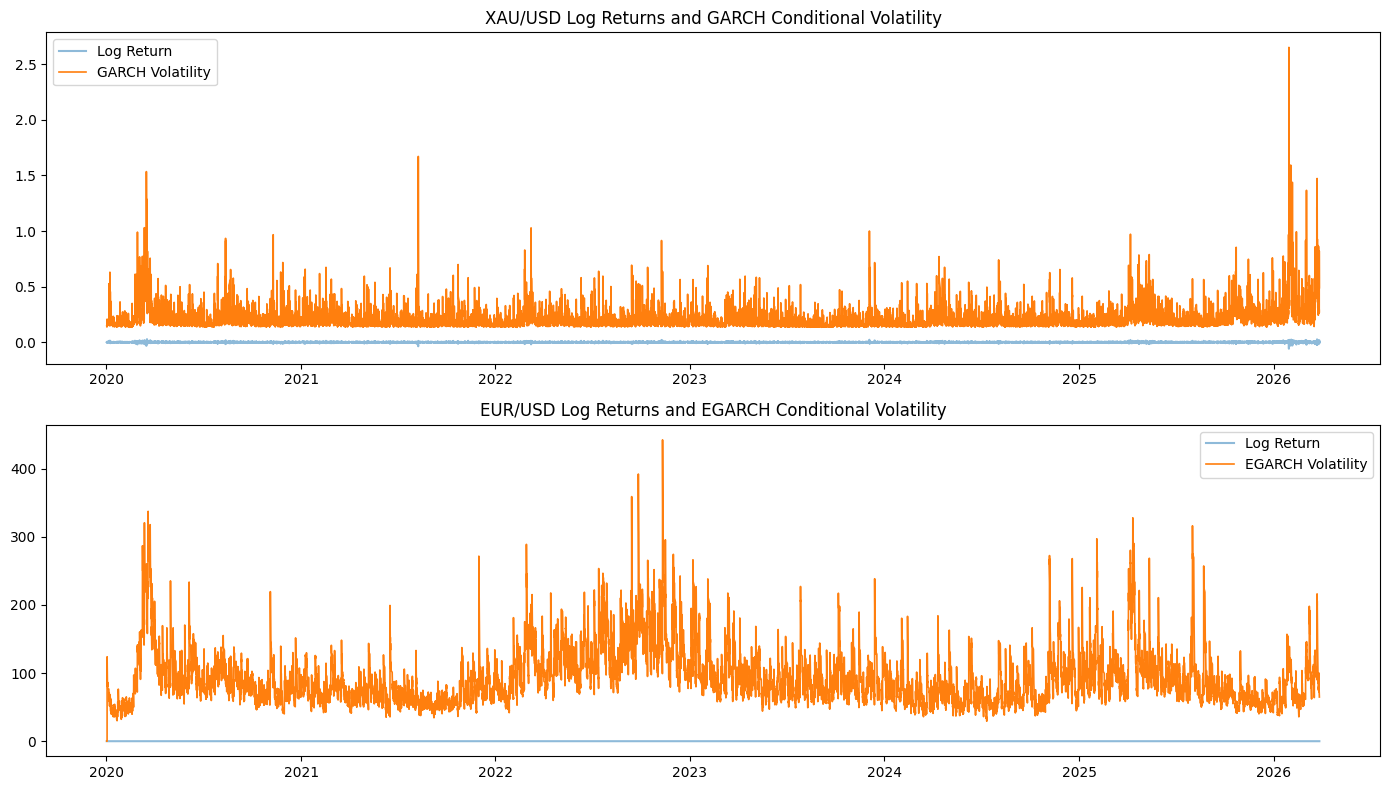

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# datetime болгох
df_xau["Datetime"] = pd.to_datetime(df_xau["Datetime"])
df_eur["Datetime"] = pd.to_datetime(df_eur["Datetime"])

# TGARCH volatility
vol_xau = garch_res_xau.conditional_volatility
vol_eur = egarch_res_eur.conditional_volatility

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# ---------------- XAU/USD ----------------
ax[0].plot(
    df_xau["Datetime"].iloc[-len(vol_xau):],
    df_xau["log_return"].dropna().iloc[-len(vol_xau):],
    alpha=0.5,
    label="Log Return"
)

ax[0].plot(
    df_xau["Datetime"].iloc[-len(vol_xau):],
    vol_xau,
    linewidth=1.2,
    label="GARCH Volatility"
)

ax[0].set_title("XAU/USD Log Returns and GARCH Conditional Volatility")
ax[0].legend()

# x-axis жилээр
ax[0].xaxis.set_major_locator(mdates.YearLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ---------------- EUR/USD ----------------
ax[1].plot(
    df_eur["Datetime"].iloc[-len(vol_eur):],
    df_eur["log_return"].dropna().iloc[-len(vol_eur):],
    alpha=0.5,
    label="Log Return"
)

ax[1].plot(
    df_eur["Datetime"].iloc[-len(vol_eur):],
    vol_eur,
    linewidth=1.2,
    label="EGARCH Volatility"
)

ax[1].set_title("EUR/USD Log Returns and EGARCH Conditional Volatility")
ax[1].legend()

ax[1].xaxis.set_major_locator(mdates.YearLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [16]:
generate_all_autocorrelation_figures(
    returns_series=df_xau["log_return"],
    fitted_model=garch_res_xau,
    asset_name="XAU/USD"
)

generate_all_autocorrelation_figures(
    returns_series=df_eur["log_return"],
    fitted_model=egarch_res_eur,
    asset_name="EUR/USD"
)

{'return_acf_pacf': WindowsPath('outputs/figures/EURUSD_return_acf_pacf.png'),
 'squared_return_acf_pacf': WindowsPath('outputs/figures/EURUSD_squared_return_acf_pacf.png'),
 'standardized_residual_acf': WindowsPath('outputs/figures/EURUSD_standardized_residual_acf.png')}

In [17]:
df_xau.columns = df_xau.columns.str.strip()
df_eur.columns = df_eur.columns.str.strip()

In [18]:
df_xau = add_candlestick_patterns(df_xau)
df_eur = add_candlestick_patterns(df_eur)

In [20]:
pattern_summary_xau = pattern_summary(
    df_xau,
    DEFAULT_PATTERN_COLS
)

pattern_summary_eur = pattern_summary(
    df_eur,
    DEFAULT_PATTERN_COLS
)

print(pattern_summary_xau)
print(pattern_summary_xau.to_latex(index=False))
print(pattern_summary_eur)
print(pattern_summary_eur.to_latex(index=False))

             Pattern  Count     Ratio
0  bearish_engulfing   2740  0.074323
1  bullish_engulfing   2751  0.074622
2               doji   3929  0.106575
3       evening_star   2057  0.055797
4             hammer    437  0.011854
5        hanging_man    493  0.013373
6       morning_star   2000  0.054251
7       spinning_top   4634  0.125698
\begin{tabular}{lrr}
\toprule
Pattern & Count & Ratio \\
\midrule
bearish_engulfing & 2740 & 0.074323 \\
bullish_engulfing & 2751 & 0.074622 \\
doji & 3929 & 0.106575 \\
evening_star & 2057 & 0.055797 \\
hammer & 437 & 0.011854 \\
hanging_man & 493 & 0.013373 \\
morning_star & 2000 & 0.054251 \\
spinning_top & 4634 & 0.125698 \\
\bottomrule
\end{tabular}

             Pattern  Count     Ratio
0  bearish_engulfing   3425  0.088275
1  bullish_engulfing   3410  0.087889
2               doji   3947  0.101729
3       evening_star   2077  0.053532
4             hammer    451  0.011624
5        hanging_man    448  0.011547
6       morning_star   2022  0.052

In [21]:
df_xau = add_forward_returns(
    df_xau,
    horizons=(1, 3, 5)
)

df_eur = add_forward_returns(
    df_eur,
    horizons=(1, 3, 5)
)

In [22]:
pattern_table_xau = build_pattern_significance_table(
    df_xau,
    asset_name="XAU/USD",
    pattern_cols=DEFAULT_PATTERN_COLS,
    horizons=(1, 3, 5)
)

pattern_table_eur = build_pattern_significance_table(
    df_eur,
    asset_name="EUR/USD",
    pattern_cols=DEFAULT_PATTERN_COLS,
    horizons=(1, 3, 5)
)

print(pattern_table_xau)
print(pattern_table_xau.to_latex(index=False))
print(pattern_table_eur)
print(pattern_table_eur.to_latex(index=False))

      Asset            Pattern  h  N_pattern  N_nonpattern  Mean_pattern  \
0   XAU/USD  bearish_engulfing  1       2740         34125     -0.000007   
1   XAU/USD  bearish_engulfing  3       2740         34123      0.000056   
2   XAU/USD  bearish_engulfing  5       2740         34121      0.000100   
3   XAU/USD  bullish_engulfing  1       2751         34114      0.000003   
4   XAU/USD  bullish_engulfing  3       2750         34113      0.000009   
5   XAU/USD  bullish_engulfing  5       2750         34111      0.000111   
6   XAU/USD               doji  1       3929         32936      0.000009   
7   XAU/USD               doji  3       3928         32935      0.000085   
8   XAU/USD               doji  5       3928         32933      0.000103   
9   XAU/USD       evening_star  1       2056         34809      0.000061   
10  XAU/USD       evening_star  3       2056         34807      0.000111   
11  XAU/USD       evening_star  5       2055         34806      0.000224   
12  XAU/USD 

In [23]:
import importlib
import thesis_pipeline.pattern_tests as pt

importlib.reload(pt)

<module 'thesis_pipeline.pattern_tests' from 'c:\\Users\\user\\Documents\\New project\\final_thesis_code\\src\\thesis_pipeline\\pattern_tests.py'>

In [24]:
df_xau = process_volume(df_xau)
df_eur = process_volume(df_eur)

In [25]:
df_xau.columns = df_xau.columns.str.strip()
df_eur.columns = df_eur.columns.str.strip()

df_xau = add_candlestick_patterns(df_xau)
df_eur = add_candlestick_patterns(df_eur)

df_xau = add_forward_returns(df_xau, horizons=(1, 3, 5))
df_eur = add_forward_returns(df_eur, horizons=(1, 3, 5))

In [26]:
volume_table_xau = build_volume_conditioned_table(
    df_xau,
    asset_name="XAU/USD",
    pattern_cols=DEFAULT_PATTERN_COLS,
    horizons=(1, 3, 5)
)

volume_table_eur = build_volume_conditioned_table(
    df_eur,
    asset_name="EUR/USD",
    pattern_cols=DEFAULT_PATTERN_COLS,
    horizons=(1, 3, 5)
)

print(volume_table_xau)
print(volume_table_xau.to_latex(index=False))
print(volume_table_eur)
print(volume_table_eur.to_latex(index=False))

      Asset            Pattern  h  N_high  Mean_high  Std_high  Median_high  \
0   XAU/USD  bearish_engulfing  1    1105  -0.000050  0.003135     0.000076   
1   XAU/USD  bearish_engulfing  3    1105  -0.000048  0.004827     0.000216   
2   XAU/USD  bearish_engulfing  5    1105  -0.000008  0.005660     0.000391   
3   XAU/USD  bullish_engulfing  1    1125   0.000013  0.002593    -0.000019   
4   XAU/USD  bullish_engulfing  3    1124  -0.000106  0.004431    -0.000043   
5   XAU/USD  bullish_engulfing  5    1124   0.000158  0.005379     0.000041   
6   XAU/USD               doji  1    1478  -0.000034  0.002433     0.000016   
7   XAU/USD               doji  3    1477   0.000007  0.004283     0.000079   
8   XAU/USD               doji  5    1477   0.000066  0.005320     0.000129   
9   XAU/USD       evening_star  1     825   0.000156  0.002935     0.000202   
10  XAU/USD       evening_star  3     825   0.000256  0.004411     0.000231   
11  XAU/USD       evening_star  5     824   0.000465

In [27]:
import importlib
import thesis_pipeline.conditional_volatility_pattern_analysis as cvpa

importlib.reload(cvpa)

<module 'thesis_pipeline.conditional_volatility_pattern_analysis' from 'c:\\Users\\user\\Documents\\New project\\final_thesis_code\\src\\thesis_pipeline\\conditional_volatility_pattern_analysis.py'>

In [28]:
garch_res_xau = fit_garch(df_xau["log_return"])
egarch_res_eur = fit_egarch(df_eur["log_return"])

vol_xau = extract_conditional_volatility(garch_res_xau).reset_index(drop=True)
vol_eur = extract_conditional_volatility(egarch_res_eur).reset_index(drop=True)

df_xau = df_xau.reset_index(drop=True)
df_eur = df_eur.reset_index(drop=True)

df_xau["garch_volatility"] = pd.NA
df_eur["garch_volatility"] = pd.NA

df_xau.loc[df_xau["log_return"].dropna().index, "garch_volatility"] = vol_xau.values
df_eur.loc[df_eur["log_return"].dropna().index, "garch_volatility"] = vol_eur.values

print(df_xau["garch_volatility"].isna().sum(), len(df_xau))
print(df_eur["garch_volatility"].isna().sum(), len(df_eur))

df_xau = add_garch_volatility_regime(df_xau, "garch_volatility")
df_eur = add_garch_volatility_regime(df_eur, "garch_volatility")

volatility_table_xau = build_volatility_conditioned_table(
    df_xau, "XAU/USD", DEFAULT_PATTERN_COLS, horizons=(1,3,5)
)

volatility_table_eur = build_volatility_conditioned_table(
    df_eur, "EUR/USD", DEFAULT_PATTERN_COLS, horizons=(1,3,5)
)

print(volatility_table_xau)
print(volatility_table_xau.to_latex(index=False))
print(volatility_table_eur)
print(volatility_table_eur.to_latex(index=False))

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.05202. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009976. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


1 36866
1 38799
      Asset            Pattern  h  High N  Low N  High Mean  Low Mean  \
0   XAU/USD  bearish_engulfing  1    1121   1619  -0.000057  0.000028   
1   XAU/USD  bearish_engulfing  3    1121   1619  -0.000082  0.000151   
2   XAU/USD  bearish_engulfing  5    1121   1619  -0.000053  0.000206   
3   XAU/USD  bullish_engulfing  1    1069   1682  -0.000139  0.000093   
4   XAU/USD  bullish_engulfing  3    1068   1682  -0.000222  0.000155   
5   XAU/USD  bullish_engulfing  5    1068   1682  -0.000137  0.000268   
6   XAU/USD               doji  1    1978   1951  -0.000028  0.000047   
7   XAU/USD               doji  3    1977   1951   0.000022  0.000149   
8   XAU/USD               doji  5    1977   1951   0.000008  0.000199   
9   XAU/USD       evening_star  1     679   1377   0.000002  0.000090   
10  XAU/USD       evening_star  3     679   1377   0.000096  0.000118   
11  XAU/USD       evening_star  5     678   1377   0.000121  0.000275   
12  XAU/USD             hammer  1  

In [29]:
pattern_directions = {
    "hammer": ["long"],
    "bullish_engulfing": ["long"],
    "morning_star": ["long"],
    "hanging_man": ["short"],
    "bearish_engulfing": ["short"],
    "evening_star": ["short"],
}

In [30]:
backtest_xau = build_backtest_table(
    df_xau,
    asset_name="XAU/USD",
    pattern_directions=pattern_directions,
    horizons=(1, 3, 5)
)

backtest_eur = build_backtest_table(
    df_eur,
    asset_name="EUR/USD",
    pattern_directions=pattern_directions,
    horizons=(1, 3, 5)
)

print(backtest_xau)
print(backtest_xau.to_latex(index=False))
print(backtest_eur)
print(backtest_eur.to_latex(index=False))

      Asset            Pattern Direction  Holding Period  total_return  \
0   XAU/USD             hammer      long               1     -0.038889   
1   XAU/USD             hammer      long               3     -0.061617   
2   XAU/USD             hammer      long               5     -0.112353   
3   XAU/USD  bullish_engulfing      long               1      0.000917   
4   XAU/USD  bullish_engulfing      long               3      0.003793   
5   XAU/USD  bullish_engulfing      long               5      0.313559   
6   XAU/USD       morning_star      long               1     -0.108479   
7   XAU/USD       morning_star      long               3      0.094803   
8   XAU/USD       morning_star      long               5      0.452114   
9   XAU/USD        hanging_man     short               1     -0.013823   
10  XAU/USD        hanging_man     short               3     -0.082519   
11  XAU/USD        hanging_man     short               5     -0.125465   
12  XAU/USD  bearish_engulfing     sho

In [31]:
from thesis_pipeline.backtesting import (
    build_backtest_table,
    backtest_pattern_strategy,
    apply_transaction_cost,
    performance_metrics,
    bootstrap_metrics
)

In [32]:
import importlib
import thesis_pipeline.backtesting as bt

importlib.reload(bt)

<module 'thesis_pipeline.backtesting' from 'c:\\Users\\user\\Documents\\New project\\final_thesis_code\\src\\thesis_pipeline\\backtesting.py'>

In [33]:
robust_xau = bt.build_backtest_robustness_table(
    df_xau,
    asset_name="XAU/USD",
    pattern_directions=pattern_directions,
    horizons=(1, 3, 5),
    transaction_cost=0.0001
)

robust_eur = bt.build_backtest_robustness_table(
    df_eur,
    asset_name="EUR/USD",
    pattern_directions=pattern_directions,
    horizons=(1, 3, 5),
    transaction_cost=0.0001
)

print(robust_xau)
print(robust_xau.to_latex(index=False))
print(robust_eur)
print(robust_eur.to_latex(index=False))

      Asset            Pattern Direction  Holding Period  Gross total_return  \
0   XAU/USD             hammer      long               1           -0.038889   
1   XAU/USD             hammer      long               3           -0.061617   
2   XAU/USD             hammer      long               5           -0.112353   
3   XAU/USD  bullish_engulfing      long               1            0.000917   
4   XAU/USD  bullish_engulfing      long               3            0.003793   
5   XAU/USD  bullish_engulfing      long               5            0.313559   
6   XAU/USD       morning_star      long               1           -0.108479   
7   XAU/USD       morning_star      long               3            0.094803   
8   XAU/USD       morning_star      long               5            0.452114   
9   XAU/USD        hanging_man     short               1           -0.013823   
10  XAU/USD        hanging_man     short               3           -0.082519   
11  XAU/USD        hanging_man     short

In [34]:
import os

os.makedirs("outputs", exist_ok=True)

# Pattern significance tables
pattern_table_xau.to_csv("outputs/pattern_table_xau.csv", index=False)
pattern_table_eur.to_csv("outputs/pattern_table_eur.csv", index=False)

# Volume-conditioned tables
volume_table_xau.to_csv("outputs/volume_table_xau.csv", index=False)
volume_table_eur.to_csv("outputs/volume_table_eur.csv", index=False)

# Volatility-conditioned tables
volatility_table_xau.to_csv("outputs/volatility_table_xau.csv", index=False)
volatility_table_eur.to_csv("outputs/volatility_table_eur.csv", index=False)

# Backtesting tables
backtest_xau.to_csv("outputs/backtest_xau.csv", index=False)
backtest_eur.to_csv("outputs/backtest_eur.csv", index=False)

# Robustness tables
robust_xau.to_csv("outputs/robust_xau.csv", index=False)
robust_eur.to_csv("outputs/robust_eur.csv", index=False)

# GARCH model comparison tables
garch_xau.to_csv("outputs/garch_xau.csv", index=False)
garch_eur.to_csv("outputs/garch_eur.csv", index=False)

print("All thesis tables exported.")

All thesis tables exported.
